# Predicción de Satisfacción de Clientes con XGBoost

---

**Autor:** Borja Mora Méndez
**Contacto:** [borja.mora.mendez@gmail.com](mailto:borja.mora.mendez@gmail.com) · [LinkedIn](https://www.linkedin.com/in/borja-mora-mendez/)
**Repositorio:** [Data Analytics Portfolio](https://github.com/BORJAMOME/Data-Analytics-Portfolio)
**Categoría:** Machine Learning · Supervisado · Clasificación · XGBoost

---

### Objetivo

Entrenar un **XGBoost Classifier** para predecir la satisfacción de clientes de un gimnasio urbano, explorar las técnicas de regularización y tuning propias de gradient boosting, y determinar si la complejidad adicional de XGBoost aporta un beneficio real frente a modelos más simples (Árbol de Decisión, Random Forest).

### Contexto de negocio

**El cliente:** cadena de gimnasios urbanos con múltiples sedes.

**El problema:** la dirección quiere identificar clientes insatisfechos antes de que se den de baja. Los indicadores operativos ya disponibles (asistencias, horas pico, gasto extra) podrían contener la señal necesaria.

## 1️. Setup: librerías y configuración visual

In [ ]:
# Librerías base
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# Preprocesamiento
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV

# Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve,
)

# Modelos
from xgboost import XGBClassifier

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", None)

# Estilo visual — sistema de color validado (consejo UX/UI Data)
BACKGROUND   = '#fbfbfb'
PURPLE       = '#7a7bff'   # único color de énfasis (1 por gráfico)
PURPLE_LIGHT = '#9b9cff'   # EDA de una sola serie (histogramas) -- PURPLE fuerte queda solo para el enfasis
POSITIVE     = '#6b8158'   # exclusivo signo positivo
NEGATIVE     = '#c34031'   # exclusivo signo negativo
NEUTRAL_BAR  = '#d9d9d9'   # barras/áreas de contexto (siempre con etiqueta de valor)
NEUTRAL_LINE = '#8f8c9e'   # líneas de contexto (más contraste que NEUTRAL_BAR)
CONTEXT_LINES = [NEUTRAL_LINE, '#a89a8a', '#7d94a8']   # gama fija para 2+ lineas de contexto en un mismo grafico
INK          = '#111111'
MUTED        = '#707070'

# Alias de compatibilidad con el resto del notebook
GREEN, RED, GRAY = POSITIVE, NEGATIVE, NEUTRAL_BAR

DIVERGING_CMAP = LinearSegmentedColormap.from_list(
    "borja_diverging", ["#c34031", "#e0a89f", "#f0ede8", "#b7c2a9", "#6b8158"]
)
SEQUENTIAL_GREEN = LinearSegmentedColormap.from_list(
    "borja_sequential", [BACKGROUND, POSITIVE]
)

def color_annotations(ax, values, threshold, dark="#ffffff", light=INK):
    """Recolorea el texto de un heatmap celda a celda según su magnitud."""
    for text, value in zip(ax.texts, np.asarray(values).flatten()):
        text.set_color(dark if abs(value) >= threshold else light)

plt.rcParams.update({
    'figure.figsize': (10, 5),
    'figure.dpi': 100,
    'figure.facecolor': BACKGROUND,
    'axes.facecolor': BACKGROUND,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.edgecolor': MUTED,
    'axes.labelcolor': INK,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlecolor': INK,
    'xtick.color': MUTED,
    'ytick.color': MUTED,
    'font.family': 'sans-serif',
    'font.size': 10,
    'grid.color': '#f0f0f0',
    'grid.linewidth': 0.5,
})

## 2. Carga de datos

In [2]:
data = pd.read_excel("gym_clientes.xlsx")
print(f"Registros: {data.shape[0]} | Columnas: {data.shape[1]}")
data.head()

Registros: 300 | Columnas: 7


,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
0,1,29,1,8.673509,64.161055,0,1
1,2,15,1,4.396600,32.554177,0,0
2,3,8,22,22.313433,85.092643,1,0
3,4,21,21,20.598791,120.709423,1,0
4,5,19,18,18.783644,103.148141,1,0


## 3. EDA: Análisis Exploratorio de datos

In [3]:
data.describe().round(2)

,ID_Cliente,Antiguedad_Meses,Asistencias_Mes,Horas_Pico_Mes,Gasto_Mensual_Extra,Satisfecho,Abandono
count,300.00,300.00,300.00,300.00,300.00,300.00,300.00
mean,150.50,18.88,12.16,14.67,81.69,0.48,0.16
std,86.75,10.60,7.27,6.09,30.47,0.50,0.37
min,1.00,1.00,0.00,1.41,10.00,0.00,0.00
25%,75.75,9.00,6.00,9.65,61.25,0.00,0.00
50%,150.50,20.00,12.00,15.07,82.24,0.00,0.00
75%,225.25,28.00,18.25,19.75,104.11,1.00,0.00
max,300.00,35.00,24.00,24.00,145.91,1.00,1.00


In [4]:
# Comprobar nulos y tipos

print('TIPOS DE DATOS Y VALORES NULOS')
print('─' * 70)
info = pd.DataFrame({
    'Tipo': data.dtypes,
    'Nulos': data.isnull().sum(),
    '% Nulos': (data.isnull().sum() / len(data) * 100).round(2),
    'Únicos': data.nunique()
})
info

TIPOS DE DATOS Y VALORES NULOS
──────────────────────────────────────────────────────────────────────


,Tipo,Nulos,% Nulos,Únicos
ID_Cliente,int64,0,0.0,300
Antiguedad_Meses,int64,0,0.0,35
Asistencias_Mes,int64,0,0.0,25
Horas_Pico_Mes,float64,0,0.0,281
Gasto_Mensual_Extra,float64,0,0.0,300
Satisfecho,int64,0,0.0,2
Abandono,int64,0,0.0,2


#### Exploración de la variable Target (Satisfecho)

In [5]:
sat_rate = data["Satisfecho"].value_counts(normalize=True)
print("Distribución del target:")
print(f"  No Satisfecho (0): {sat_rate[0]:.1%}")
print(f"  Satisfecho (1):    {sat_rate[1]:.1%}")
print("\nClases equilibradas (52/48)")

Distribución del target:
  No Satisfecho (0): 52.0%
  Satisfecho (1):    48.0%

Clases equilibradas (52/48)


In [ ]:
# Distribuciones de cada variable

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
fig.suptitle('Distribuciones de las variables', fontsize=14, fontweight='bold', color=INK, y=1.00)

variables = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]
for ax, var in zip(axes.flat, variables):
    ax.hist(data[var], bins=20, color=PURPLE_LIGHT, edgecolor='white', alpha=0.85)
    ax.axvline(data[var].mean(), color=INK, linestyle='--', linewidth=1.5, label=f'Media: {data[var].mean():.1f}')
    ax.axvline(data[var].median(), color=NEUTRAL_LINE, linestyle='--', linewidth=1.5, label=f'Mediana: {data[var].median():.1f}')
    ax.set_title(var, color=INK)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Matriz de correlación

cols_num = ["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]

# Matriz de correlación
corr = data[cols_num].corr()

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".4f",
    cmap=DIVERGING_CMAP,
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=2,
    linecolor=BACKGROUND,
    cbar_kws={"shrink": 0.75},
    annot_kws={"size": 10, "weight": "bold"},
)
color_annotations(ax, corr.values, threshold=0.8)

ax.set_title(
    "Matriz de correlación de Pearson",
    fontsize=14,
    fontweight="bold",
    color=INK,
    pad=18,
)

ax.tick_params(colors=INK)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Columna del target (Satisfacción)

- ``Asistencias_Mes``: correlación positiva fuerte → los clientes que acuden con mayor frecuencia al gimnasio tienden a mostrar una mayor satisfacción.
- ``Horas_Pico_Mes``: correlación positiva fuerte → un mayor uso de las instalaciones, incluso en horas punta, está asociado con clientes más satisfechos.
- ``Gasto_Mensual_Extra``: correlación positiva fuerte → los clientes que invierten más en servicios adicionales suelen presentar niveles más altos de satisfacción.
- ``Antiguedad_Meses``: correlación positiva moderada → los clientes con más tiempo en el gimnasio muestran una ligera tendencia a estar más satisfechos, aunque la relación es menor que en el resto de variables.

### Entre variables predictoras

- ``Antiguedad_Meses ↔ Asistencias_Mes``: **-0.0734** → correlación muy débil y negativa.
- ``Antiguedad_Meses ↔ Horas_Pico_Mes``: **-0.0248** → correlación prácticamente nula.
- ``Antiguedad_Meses ↔ Gasto_Mensual_Extra``: **0.3838** → correlación moderada y positiva.
- ``Asistencias_Mes ↔ Horas_Pico_Mes``: **0.9425** → correlación muy fuerte y positiva.
- ``Asistencias_Mes ↔ Gasto_Mensual_Extra``: **0.8241** → correlación fuerte y positiva.
- ``Horas_Pico_Mes ↔ Gasto_Mensual_Extra``: **0.7959** → correlación fuerte y positiva.

### Conclusión

Las variables relacionadas con el **uso del gimnasio** (asistencia, horas de uso y gasto en servicios adicionales) muestran una relación positiva con la satisfacción de los clientes, lo que indica que los usuarios más implicados suelen estar más satisfechos.

Además, existe una correlación muy elevada entre ``Asistencias_Mes`` y ``Horas_Pico_Mes`` (**0.9425**), por lo que ambas variables aportan información muy similar.

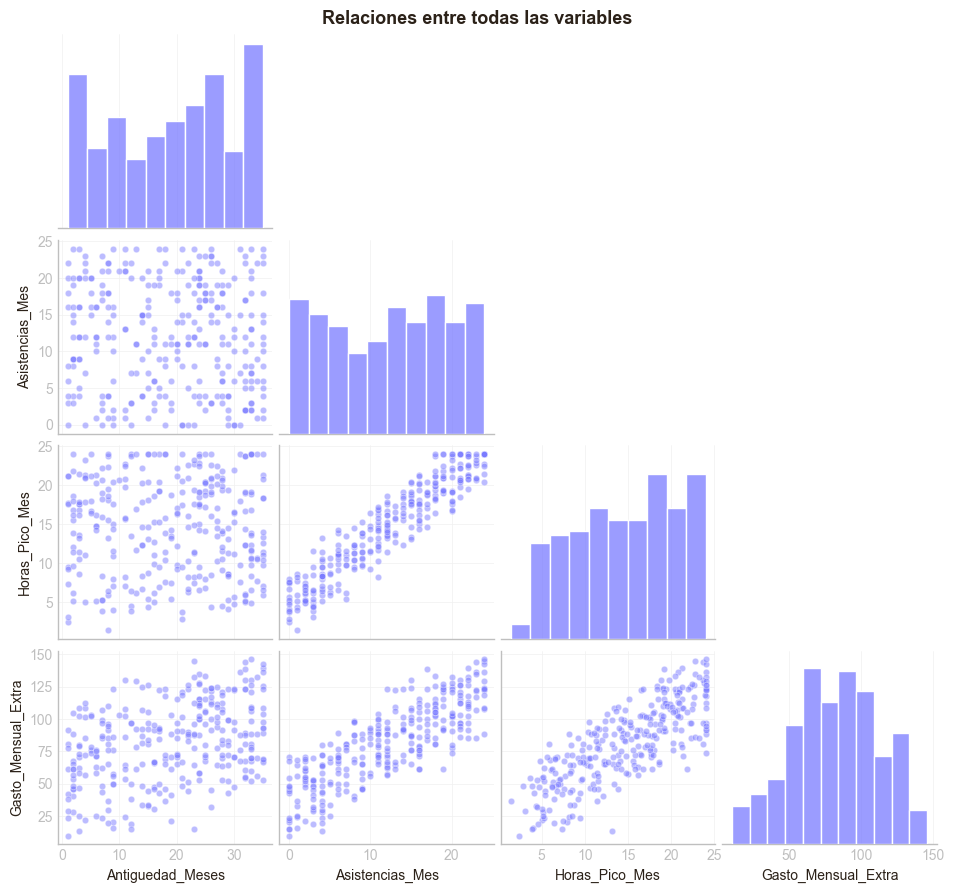

In [8]:
# Pair plot: relaciones por parejas
g = sns.pairplot(
    data[cols_num], height=2.2, aspect=1.1,
    plot_kws={'color': PURPLE, 'alpha': 0.5, 's': 22, 'edgecolor': 'white', 'linewidth': 0.5},
    diag_kws={'color': PURPLE, 'edgecolor': 'white'},
    corner=True
)
g.fig.suptitle('Relaciones entre todas las variables', y=1.01, fontsize=13, fontweight='bold', color=INK)
plt.show()

## 4. Train / Test Split
Excluimos `Abandono` para evitar data leakage — un cliente que se ha dado de baja es, por definición, insatisfecho. Si la incluyéramos, el modelo "haría trampa".

In [9]:
X = data[["Antiguedad_Meses", "Asistencias_Mes", "Horas_Pico_Mes", "Gasto_Mensual_Extra"]]
y = data["Satisfecho"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} registros ({y_train.mean():.1%} satisfechos)")
print(f"Test:  {X_test.shape[0]} registros ({y_test.mean():.1%} satisfechos)")

Train: 240 registros (47.9% satisfechos)
Test:  60 registros (48.3% satisfechos)


## 5. Modelo principal — XGBoost

In [10]:
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [2, 3, 4],
    "learning_rate": [0.05, 0.1, 0.2],
}

xgb_base = XGBClassifier(
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False,
)

grid = GridSearchCV(
    xgb_base, param_grid, cv=5, scoring="accuracy",
    n_jobs=-1, return_train_score=True
)
grid.fit(X_train, y_train)

print(f"Mejor combinación: {grid.best_params_}")
print(f"CV Accuracy:       {grid.best_score_:.4f}")

Mejor combinación: {'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 100}
CV Accuracy:       0.9208


c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:56:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### Selección de hiperparámetros
Para optimizar el rendimiento del modelo se realizó una búsqueda mediante el combinando distintos valores de los principales hiperparámetros de XGBoost:

- **n_estimators:** 50, 100 y 200 árboles.
- **max_depth:** 2, 3 y 4 niveles de profundidad.
- **learning_rate:** 0.05, 0.10 y 0.20.

En total se evaluaron **27 combinaciones** de parámetros utilizando **validación cruzada de 5 particiones (5-fold)**.

Mejor configuración encontrada

- ``learning_rate``: **0.05**
- ``max_depth``: **4**
- ``n_estimators``: **100**

Resultado de la validación cruzada

- **Accuracy media (CV 5-fold):** **92,08%**

####  Conclusión

La búsqueda de hiperparámetros muestra que el mejor equilibrio entre capacidad predictiva y generalización se obtiene con **100 árboles**, una **profundidad máxima de 4 niveles** y una **tasa de aprendizaje de 0,05**.

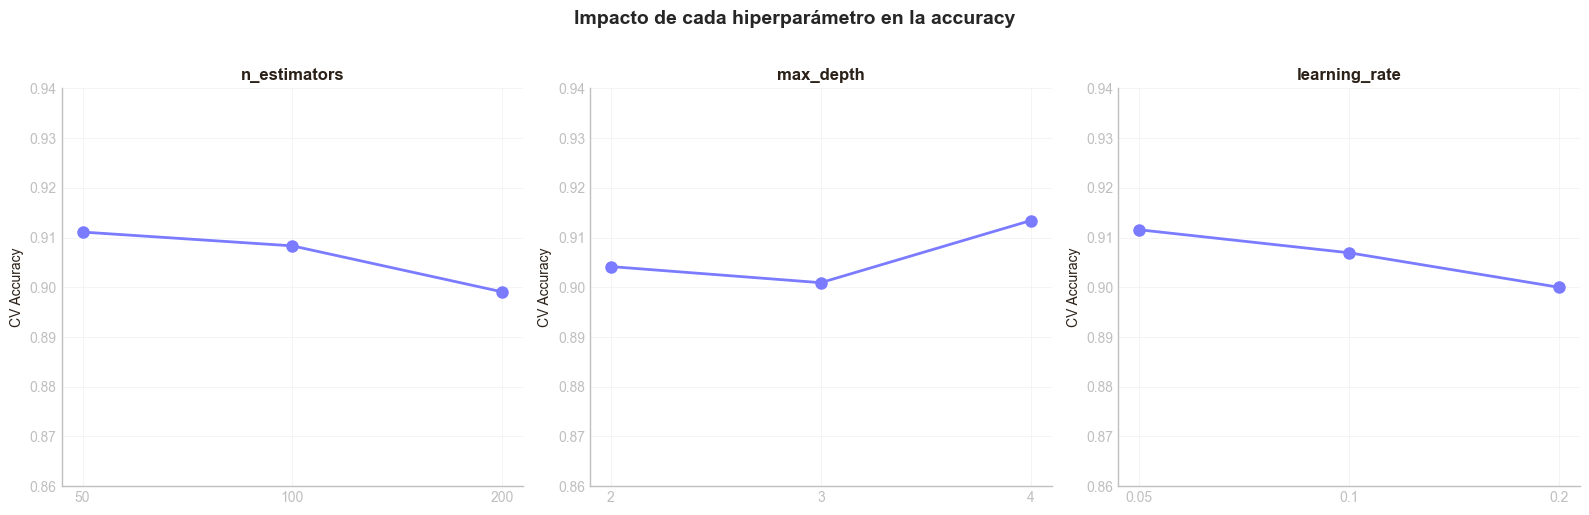

In [11]:
# Visualizar el impacto de cada hiperparámetro
results = pd.DataFrame(grid.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, param in zip(axes, ["param_n_estimators", "param_max_depth", "param_learning_rate"]):
    grouped = results.groupby(param)["mean_test_score"].mean()
    ax.plot(grouped.index.astype(str), grouped.values, marker="o", color=PURPLE, linewidth=2, markersize=8)
    ax.set_title(param.replace("param_", ""), fontsize=12, fontweight="bold")
    ax.set_ylabel("CV Accuracy")
    ax.set_ylim(0.86, 0.94)

plt.suptitle("Impacto de cada hiperparámetro en la accuracy", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Entrenamiento del modelo final

In [12]:
xgb = XGBClassifier(
    **grid.best_params_,
    eval_metric="logloss",
    random_state=42,
    use_label_encoder=False,
)
xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
y_proba = xgb.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print("XGBoost — Métricas de evaluación")
print(f"Accuracy:  {acc:.1%}")
print(f"Recall:    {rec:.1%}")
print(f"AUC-ROC:   {auc:.3f}")
print()
print(classification_report(y_test, y_pred, target_names=["No Satisfecho", "Satisfecho"]))

XGBoost — Métricas de evaluación
Accuracy:  91.7%
Recall:    93.1%
AUC-ROC:   0.917

               precision    recall  f1-score   support

No Satisfecho       0.93      0.90      0.92        31
   Satisfecho       0.90      0.93      0.92        29

     accuracy                           0.92        60
    macro avg       0.92      0.92      0.92        60
 weighted avg       0.92      0.92      0.92        60



c:\Users\borja\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\training.py:200: UserWarning: [15:56:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


#### Evaluación del modelo

El modelo XGBoost obtiene un rendimiento muy equilibrado en el conjunto de prueba:

#### Interpretación de las métricas

- **Accuracy (91,7%)**: el modelo clasifica correctamente aproximadamente **9 de cada 10 clientes**, mostrando un alto nivel de precisión global.

- **Recall (93,1%)**: identifica correctamente el **93,1% de los clientes satisfechos**, minimizando el número de falsos negativos. Esto resulta especialmente útil cuando el objetivo es detectar correctamente a los clientes con mayor probabilidad de estar satisfechos.

- **AUC-ROC (0,917)**: el modelo presenta una excelente capacidad para distinguir entre clientes satisfechos y no satisfechos, independientemente del umbral de clasificación utilizado.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap=SEQUENTIAL_GREEN,
            linewidths=2, linecolor=BACKGROUND,
            xticklabels=["No Satisfecho", "Satisfecho"],
            yticklabels=["No Satisfecho", "Satisfecho"], ax=axes[0],
            annot_kws={"size": 12, "weight": "bold"})
color_annotations(axes[0], cm, threshold=cm.max() * 0.6)
axes[0].set_title("Matriz de confusión — XGBoost", fontsize=12, fontweight="bold", color=INK)
axes[0].set_xlabel("Predicción")
axes[0].set_ylabel("Real")

# Curva ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color=PURPLE, linewidth=2, label=f"XGBoost (AUC = {auc:.3f})")
axes[1].plot([0, 1], [0, 1], color=INK, linestyle="--", linewidth=1, label="Random (AUC = 0.500)")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("Curva ROC", fontsize=12, fontweight="bold")
axes[1].legend()

plt.tight_layout()
plt.show()

#### Matriz de confusión

- **28** clientes **No Satisfechos** fueron clasificados correctamente.
- **27** clientes **Satisfechos** fueron clasificados correctamente.
- **3** clientes **No Satisfechos** fueron clasificados como **Satisfechos** (*falsos positivos*).
- **2** clientes **Satisfechos** fueron clasificados como **No Satisfechos** (*falsos negativos*).

En total, el modelo clasifica correctamente **55 de los 60 clientes**, lo que equivale a una **accuracy del 91,7%**.

#### Curva ROC

**AUC-ROC = 0,917**: el modelo asigna una mayor probabilidad de satisfacción a los clientes realmente satisfechos en la gran mayoría de los casos.


### Importancia de variables en XGBoost

In [ ]:
imp = pd.DataFrame({
    "feature": X.columns,
    "importance": xgb.feature_importances_
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
top_feature = imp["importance"].idxmax()
colors = [PURPLE if i == top_feature else NEUTRAL_BAR for i in imp.index]
bars = ax.barh(imp["feature"], imp["importance"], color=colors)
for bar, v, i in zip(bars, imp["importance"], imp.index):
    is_top = i == top_feature
    ax.text(v + 0.005, bar.get_y() + bar.get_height()/2, f"{v:.1%}",
            va="center", fontsize=10, color=INK, fontweight="bold" if is_top else "normal")
ax.set_title("XGBoost — Importancia de variables (gain)", fontsize=13, fontweight="bold")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

print("Ranking de importancia:")
for _, row in imp.sort_values("importance", ascending=False).iterrows():
    print(f"  {row['feature']:25s} {row['importance']:.1%}")

## 6. Insights de negocio y recomendaciones

XGBoost confirma de forma aún más contundente que la **frecuencia de asistencia al gimnasio** es el principal factor que explica la satisfacción de los clientes. Esta variable concentra el **80,8% de la importancia** del modelo, mientras que el resto (gasto adicional, uso en horas punta y antigüedad) tienen una contribución mucho menor.

### Recomendaciones

**1. Convertir la asistencia en el principal KPI de negocio**

La frecuencia de asistencia debe convertirse en el indicador principal para monitorizar la satisfacción de los clientes. Al concentrar el **80,8% de la capacidad predictiva**, es el mejor predictor disponible para anticipar el comportamiento de los usuarios.

**2. Activar campañas de fidelización cuando disminuya la asistencia**

Más que centrarse en la antigüedad o en el gasto en servicios adicionales, el gimnasio debería detectar rápidamente a los clientes cuya frecuencia de asistencia empiece a disminuir y activar acciones preventivas como recordatorios, promociones o sesiones de seguimiento.

**3. Utilizar las variables secundarias como apoyo**

El **Gasto_Mensual_Extra (7,2%)**, las **Horas_Pico_Mes (6,3%)** y la **Antigüedad_Meses (5,7%)** aportan información adicional, pero su influencia es claramente inferior. Estas variables pueden ayudar a personalizar las acciones comerciales, aunque no deberían ser el criterio principal para evaluar la satisfacción.